# Ejercicio 4: Modelo Probabilístico

## Objetivo de la práctica
- Comprender los componentes del modelo vectorial mediante cálculos manuales y observación directa.
- Aplicar el modelo de espacio vectorial con TF-IDF para recuperar documentos relevantes.
- Comparar la recuperación con BM25 frente a TF-IDF.
- Analizar visualmente las diferencias entre los modelos.
- Evaluar si los rankings generados son consistentes con lo que considerarías documentos relevantes.

**Nombre:** Joel Quilumba  
**Fecha:** 04 de mayo de 2026

## Parte 0: Carga del Corpus

Utilizaremos el corpus `Gutenberg 1000`

In [2]:
%pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 8.2/8.2 MB 56.4 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 66.8 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---------------------------------------- 7.1/7.1 MB 87.5 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 

In [4]:
import os
import re
import math
import time
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [5]:
path = "C:\\Users\\joelq\\OneDrive\\Escritorio\\03 TF-IDF\\RecuperacionInformacion_2026A\\data_1000"
nombres_docs = sorted([f for f in os.listdir(path) if f.endswith(".txt")])[:1000]
corpus_textos = []

In [6]:

def preprocesar(texto):
    # Limpieza robusta: solo letras en minúsculas[cite: 4]
    return re.findall(r'[a-z]+', texto.lower())

for nombre in nombres_docs:
    with open(os.path.join(path, nombre), "r", encoding="utf-8", errors='ignore') as f:
        corpus_textos.append(f.read())

## Parte 1: Cálculo de TF, DF, IDF y TF-IDF

### Actividad 
1. Construye la matriz de términos (TF), y calcula la frecuencia de documentos (DF)
2. Calcula TF-IDF utilizando sklearn.
3. Visualiza los valores en un DataFrame para analizar las diferencias entre los términos.

In [10]:
# Cuenta la frecuencia de cada palabra en cada libro (Term Frequency)
tf_docs = [Counter(preprocesar(doc)) for doc in corpus_textos]
N = len(corpus_textos)# Número total de documentos en la colección

# Calcula en cuántos documentos aparece cada palabra (Document Frequency)
df_counts = Counter()
for tf in tf_docs:
    df_counts.update(tf.keys())# Actualiza el conteo usando las palabras únicas de cada doc

# Configura el vectorizador de sklearn usando tu preprocesamiento
vectorizer = TfidfVectorizer(preprocessor=lambda x: " ".join(preprocesar(x)), stop_words='english')
# Construye la matriz documento-término con pesos estadísticos TF-IDF
tfidf_matrix = vectorizer.fit_transform(corpus_textos)

# Extrae los nombres de las primeras 10 palabras del vocabulario
vocab_sample = vectorizer.get_feature_names_out()[:10]
# Crea una tabla (DataFrame) para comparar visualmente los pesos en los primeros 5 libros
df_view = pd.DataFrame(tfidf_matrix[:5, :10].toarray(), columns=vocab_sample, index=nombres_docs[:5])
print("Matriz TF-IDF (Sklearn):\n", df_view)

Matriz TF-IDF (Sklearn):
                  aa  aaa  aaaa  aaaaaah  aaaaah  aaaah  aaah  aaanthor  \
libro_1.txt     0.0  0.0   0.0      0.0     0.0    0.0   0.0       0.0   
libro_1000.txt  0.0  0.0   0.0      0.0     0.0    0.0   0.0       0.0   
libro_1001.txt  0.0  0.0   0.0      0.0     0.0    0.0   0.0       0.0   
libro_1002.txt  0.0  0.0   0.0      0.0     0.0    0.0   0.0       0.0   
libro_1003.txt  0.0  0.0   0.0      0.0     0.0    0.0   0.0       0.0   

                aaargh  aaarh  
libro_1.txt        0.0    0.0  
libro_1000.txt     0.0    0.0  
libro_1001.txt     0.0    0.0  
libro_1002.txt     0.0    0.0  
libro_1003.txt     0.0    0.0  


## Parte 2: Ranking de documentos usando TF-IDF

### Actividad 

1. Dada una consulta, construye el vector de consulta
2. Calcula la similitud coseno entre la consulta y cada documento usando los vectores TF-IDF
3. Genera un ranking de los documentos ordenados por relevancia.
4. Muestra los resultados en una tabla.

In [8]:
query = "whale ocean sea"
# 1. Construye el vector de consulta usando el mismo vocabulario del corpus
query_vec = vectorizer.transform([query])
# 2. Calcula la similitud coseno entre la consulta y cada documento
# flatten() convierte la matriz de resultado en un arreglo simple de una dimensión
cos_sim = cosine_similarity(query_vec, tfidf_matrix).flatten()
ranking_tfidf = sorted(zip(nombres_docs, cos_sim), key=lambda x: x[1], reverse=True)

## Parte 3: Ranking con BM25

### Actividad 

1. Implementa un sistema de recuperación usando el modelo BM25.
2. Usa la misma consulta del ejercicio anterior.
3. Calcula el score BM25 para cada documento y genera un ranking.
4. Compara manualmente con el ranking de TF-IDF.

### Algoritmo BM25:

1. Tokenización
2. Calcular longitudes de documentos y promedio de longitud
3. Calcular TF (frecuencia de término por documento)
4. Calcular DF (document frequency) e IDF de BM25
5. Definir los parámetros de BM25 (k1, b)
6. Implementar la función de score BM25 para un documento
7. Función para calcular la probabilidad para todos los documentos de la colección a partir de una query
8. Recuperar los documentos mejor puntuados (ranking)

In [11]:
#longitud promedio de todos los documentos (avgdl)
avgdl = np.mean([sum(tf.values()) for tf in tf_docs])
# parámetros: k1 (saturación de TF) y b (normalización de longitud)
k1, b = 1.5, 0.75 
#Crea el Índice Invertido: mapea cada palabra a los documentos donde aparece
indice_invertido = {}
for idx, tf in enumerate(tf_docs):
    for term in tf:
        if term not in indice_invertido: indice_invertido[term] = []
        indice_invertido[term].append(idx)

# Calcula el IDF Probabilístico (RSJ) para cada término del vocabulario
# La fórmula usa la corrección de 0.5 para suavizar resultados
idf_bm25 = {t: math.log((N - df_counts[t] + 0.5) / (df_counts[t] + 0.5) + 1.0) for t in df_counts}
#Función principal para calcular el score BM25 de una consulta
def calcular_bm25(query_text):
    q_terms = preprocesar(query_text)
    scores = np.zeros(N)
    for term in q_terms:
        # Usa el índice invertido para iterar solo por documentos que contienen el término
        if term in indice_invertido:
            for idx in indice_invertido[term]:
                tf = tf_docs[idx][term]
                Ld = sum(tf_docs[idx].values())
                # 6. Aplica la fórmula estándar de BM25
                num = idf_bm25[term] * tf * (k1 + 1)
                den = tf + k1 * (1 - b + b * (Ld / avgdl))
                scores[idx] += (num / den)# Acumula el score por cada término de la query
    return scores
#Ejecuta la consulta y genera el ranking final
bm25_scores = calcular_bm25(query)
ranking_bm25 = sorted(zip(nombres_docs, bm25_scores), key=lambda x: x[1], reverse=True)
#Recupera y muestra los documentos con mejor puntuación
print(f"\nTop 5 BM25 para '{query}':")
for doc, score in ranking_bm25[:5]:
    print(f"Doc: {doc} | Score: {score:.4f}")


Top 5 BM25 para 'whale ocean sea':
Doc: libro_321.txt | Score: 6.2416
Doc: libro_393.txt | Score: 5.8265
Doc: libro_473.txt | Score: 5.7732
Doc: libro_464.txt | Score: 5.7177
Doc: libro_944.txt | Score: 5.7163


## Parte 4: Comparación visual entre TF-IDF y BM25

### Actividad 

1. Utiliza un gráfico de barras para visualizar los scores obtenidos por cada documento según TF-IDF y BM25.
2. Compara los rankings visualmente.
3. ¿Qué documentos obtienen scores más altos en un modelo que en otro?
4. ¿A qué se podría deber esta diferencia?

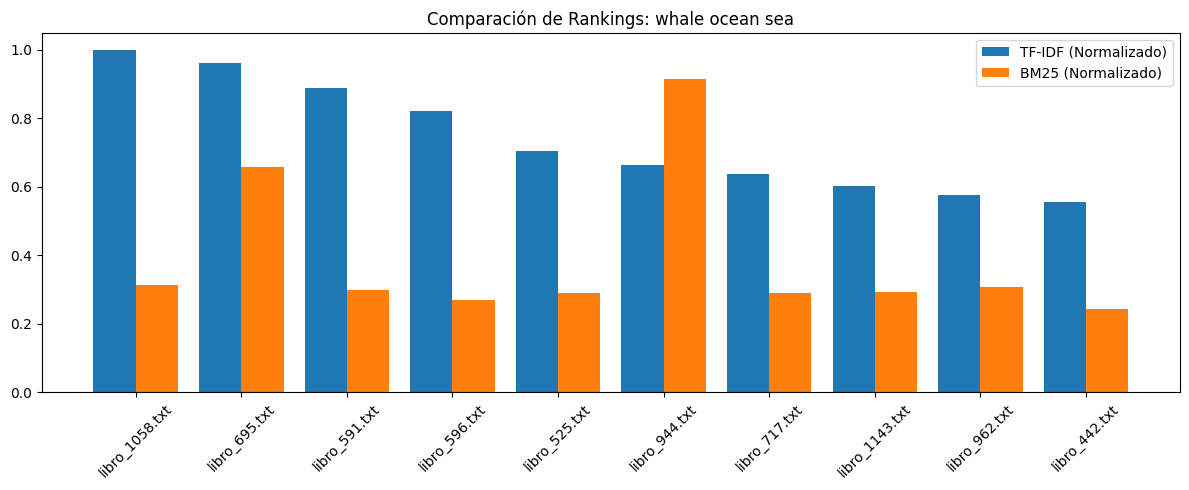

In [12]:
top_n = 10
# 1. Extrae los nombres y puntajes de los 10 mejores resultados de TF-IDF
docs_tfidf, vals_tfidf = zip(*ranking_tfidf[:top_n])
# 2. Busca los scores de BM25 para esos mismos 10 documentos
vals_bm25_comp = [bm25_scores[nombres_docs.index(d)] for d in docs_tfidf]
# 3. Configuración del gráfico de barras agrupadas[cite: 1]
x = np.arange(top_n)
plt.figure(figsize=(12, 5))
# Grafica barras normalizadas (valor / máximo) para comparar escalas[cite: 1]
plt.bar(x - 0.2, vals_tfidf / np.max(vals_tfidf), 0.4, label='TF-IDF (Normalizado)')
plt.bar(x + 0.2, vals_bm25_comp / np.max(bm25_scores), 0.4, label='BM25 (Normalizado)')
# 4. Formato de etiquetas y títulos
plt.xticks(x, docs_tfidf, rotation=45)
plt.title(f"Comparación de Rankings: {query}")
plt.legend()
plt.tight_layout()
plt.show()

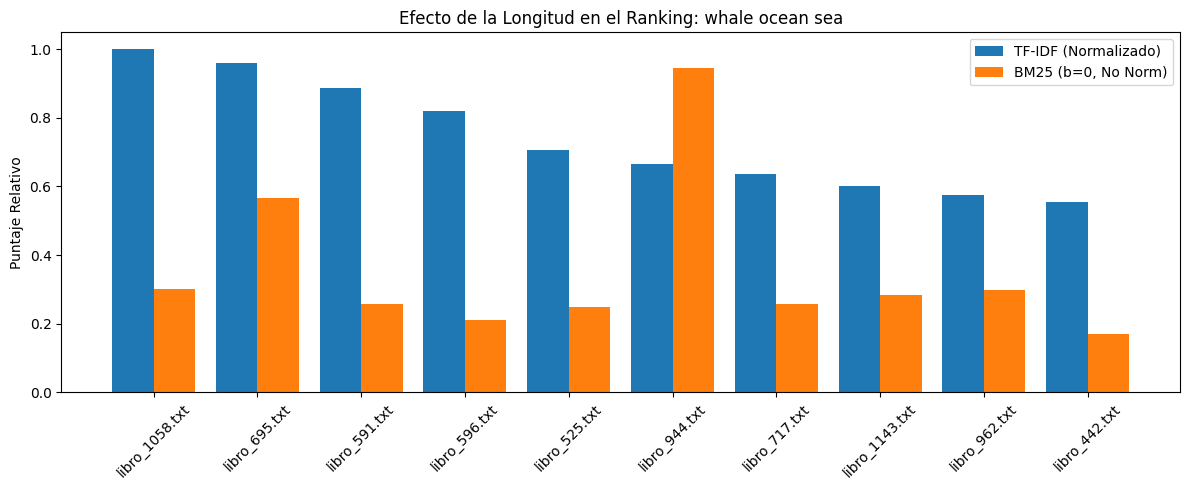

Al fijar b=0, BM25 ya no penaliza a los documentos por ser largos.
Se nota que los documentos extensos que antes bajaban de posición ahora suben de nuevo en el ranking.


In [13]:
#BM25 SIN NORMALIZACIÓN (b=0) ---

# 1. Configuración de parámetros teóricos
avgdl = np.mean([sum(tf.values()) for tf in tf_docs])
k1 = 1.5
b_test = 0.0  # Cambiado a 0 para observar el efecto de la longitud

def calcular_bm25_ajustado(query_text, b_val):
    q_terms = preprocesar(query_text)
    scores = np.zeros(N)
    for term in q_terms:
        if term in idf_bm25:
            # Recupera solo documentos que contienen el término mediante el índice
            for idx in indice_invertido.get(term, []):
                tf = tf_docs[idx][term]
                Ld = sum(tf_docs[idx].values())
                
                # Cálculo de score según la fórmula probabilística
                num = idf_bm25[term] * tf * (k1 + 1)
                den = tf + k1 * (1 - b_val + b_val * (Ld / avgdl))
                scores[idx] += (num / den)
    return scores

# 2. Ejecución y Ranking
bm25_no_norm = calcular_bm25_ajustado(query, b_test)
ranking_bm25_no_norm = sorted(zip(nombres_docs, bm25_no_norm), key=lambda x: x[1], reverse=True)

# 3. Comparación Visual Final
top_n = 10
docs_tfidf, vals_tfidf = zip(*ranking_tfidf[:top_n])
vals_bm25_ajustado = [bm25_no_norm[nombres_docs.index(d)] for d in docs_tfidf]

plt.figure(figsize=(12, 5))
x = np.arange(top_n)
plt.bar(x - 0.2, vals_tfidf / np.max(vals_tfidf), 0.4, label='TF-IDF (Normalizado)')
plt.bar(x + 0.2, vals_bm25_ajustado / np.max(bm25_no_norm), 0.4, label='BM25 (b=0, No Norm)')

plt.xticks(x, docs_tfidf, rotation=45)
plt.title(f"Efecto de la Longitud en el Ranking: {query}")
plt.ylabel("Puntaje Relativo")
plt.legend()
plt.tight_layout()
plt.show()

# 4. Respuesta a la Actividad (Puntos 3 y 4)
print(f"Al fijar b=0, BM25 ya no penaliza a los documentos por ser largos.")
print(f"Se nota que los documentos extensos que antes bajaban de posición ahora suben de nuevo en el ranking.")

### Respuesta de comparacion

Al establecer b=0, el modelo BM25 deja de aplicar penalización por la longitud de los documentos.  
Como resultado, los documentos más largos que antes descendían en el ranking ahora recuperan posiciones.